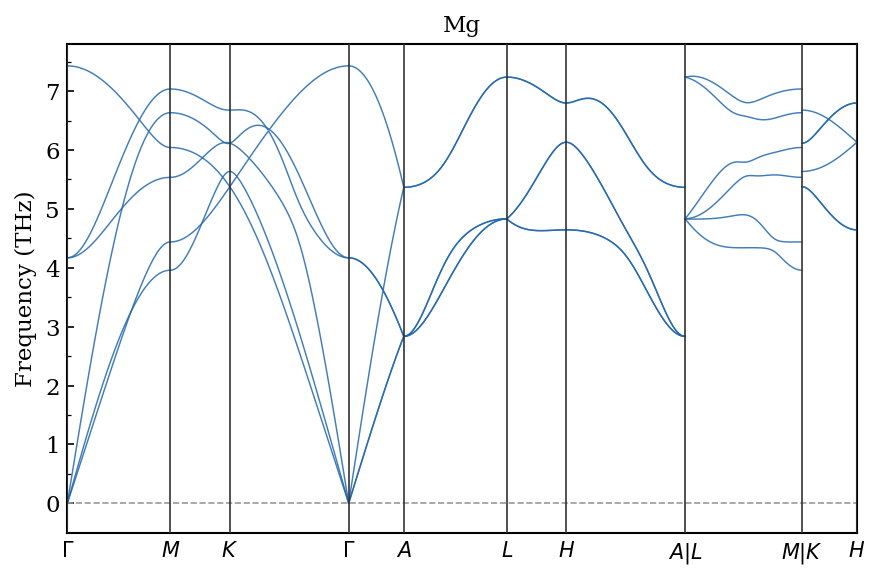

Saved: phonon_Mg_corrected.pdf  |  max freq = 7.4 THz


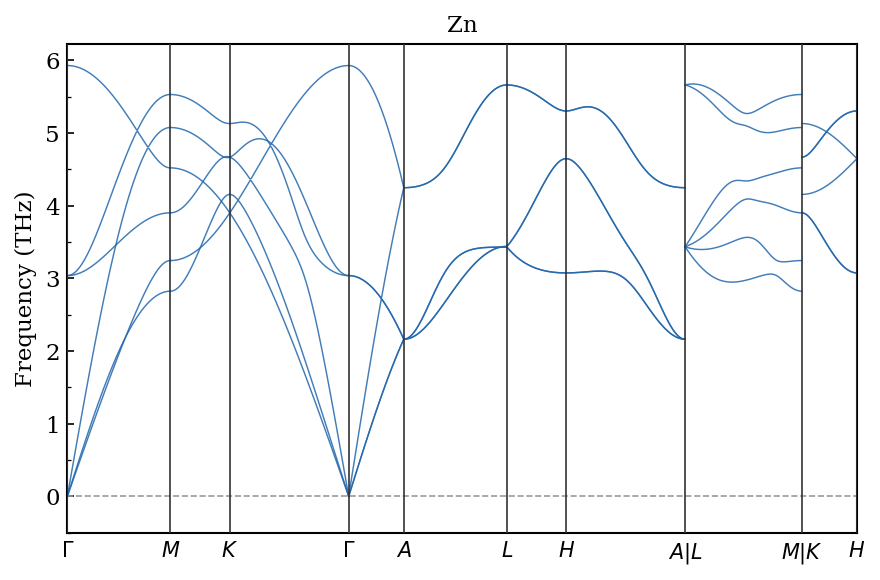

Saved: phonon_Zn_corrected.pdf  |  max freq = 5.9 THz


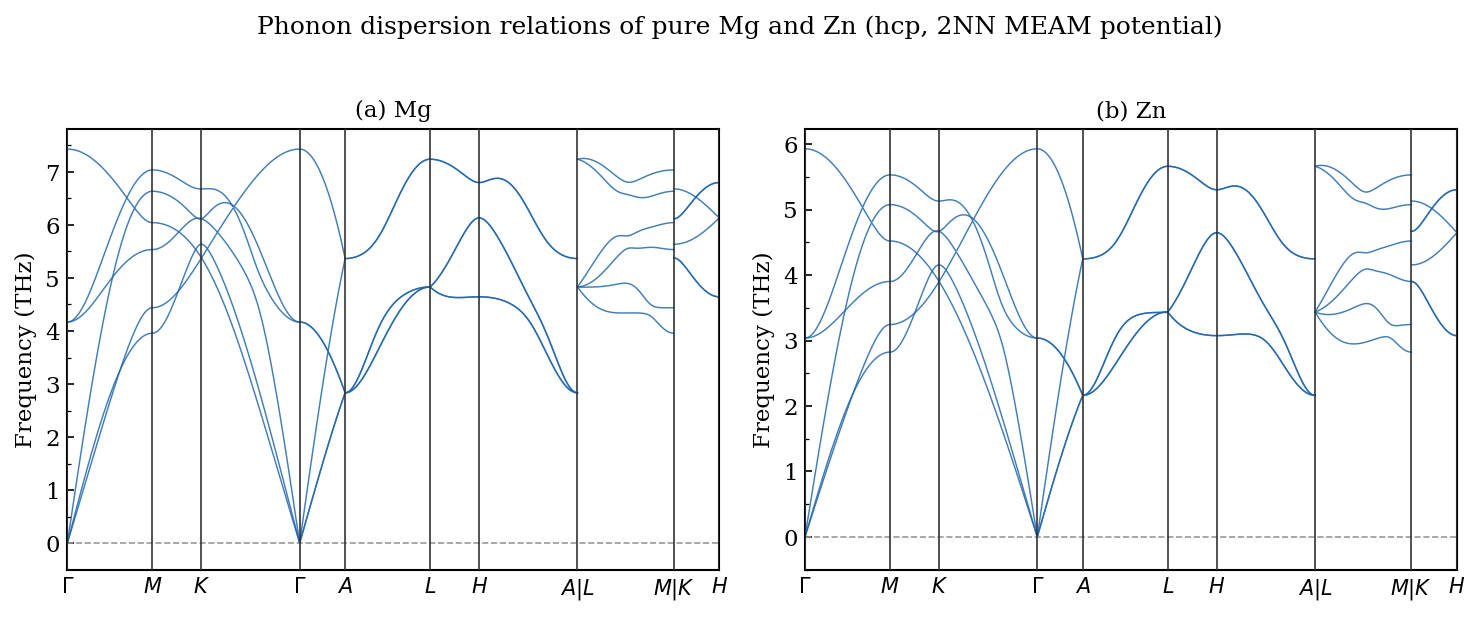

Saved: phonon_Mg_Zn_comparison_corrected.pdf


In [1]:
#!/usr/bin/env python3
"""
Pure element phonon dispersions with mass corrections applied
"""
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        150,
    'axes.linewidth':    1.0,
    'lines.linewidth':   0.8,
})

BAND_COLOUR  = '#2166ac'
ZERO_COLOUR  = '#999999'
VLINE_COLOUR = '#333333'

# ═══════════════════════════════════════════════════════════════════
# MASS CORRECTION FACTORS
# ═══════════════════════════════════════════════════════════════════
MASS_CORRECTIONS = {
    'Mg': np.sqrt(1.008 / 24.305),  # 0.2036
    'Zn': np.sqrt(1.008 / 65.38),   # 0.1241
}

ELEMENT_YAML_FILES = {
    'Mg': 'Mg unitcell/mg_band.yaml',
    'Zn': 'Zn unitcell/zn_band.yaml',
}

# Standard hcp Brillouin zone high-symmetry labels (P6_3/mmc)
HCP_LABELS = {
    (0.0,   0.0,   0.0):  r'$\Gamma$',
    (0.5,   0.0,   0.0):  r'$M$',
    (0.333, 0.333, 0.0):  r'$K$',
    (0.0,   0.0,   0.5):  r'$A$',
    (0.0,   0.5,   0.5):  r'$L$',
    (0.333, 0.333, 0.5):  r'$H$',
}

def round_q(q, decimals=3):
    return tuple(round(x, decimals) for x in q)

def plot_band(ax, yaml_path, label_dict, title, correction_factor=1.0):
    """
    Plot phonon band structure with mass correction applied.
    
    correction_factor: multiply all frequencies by this factor
    """
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    segments   = data['segment_nqpoint']
    phonon_pts = data['phonon']

    distances = np.array([pt['distance'] for pt in phonon_pts])
    
    freqs = np.array([[b['frequency'] for b in pt['band']]
                      for pt in phonon_pts]) * correction_factor
    
    seg_starts = [0]
    for s in segments[:-1]:
        seg_starts.append(seg_starts[-1] + s)

    for i, start in enumerate(seg_starts):
        end = start + segments[i]
        ax.plot(distances[start:end], freqs[start:end, :],
                color=BAND_COLOUR, lw=0.7, alpha=0.85)

    vline_pos    = []
    vline_labels = []

    idx = 0
    for i, s in enumerate(segments):
        q_start   = round_q(phonon_pts[idx]['q-position'])
        q_end     = round_q(phonon_pts[idx + s - 1]['q-position'])
        d_start   = phonon_pts[idx]['distance']
        d_end     = phonon_pts[idx + s - 1]['distance']
        lbl_start = label_dict.get(q_start, '')
        lbl_end   = label_dict.get(q_end,   '')

        if not vline_pos or abs(d_start - vline_pos[-1]) > 1e-6:
            vline_pos.append(d_start)
            vline_labels.append(lbl_start)
        else:
            prev = vline_labels[-1]
            if lbl_start and lbl_start != prev:
                vline_labels[-1] = prev + r'$|$' + lbl_start

        if abs(d_end - vline_pos[-1]) > 1e-6:
            vline_pos.append(d_end)
            vline_labels.append(lbl_end)
        else:
            prev = vline_labels[-1]
            if lbl_end and lbl_end != prev:
                vline_labels[-1] = prev + r'$|$' + lbl_end

        idx += s

    for pos in vline_pos:
        ax.axvline(x=pos, color=VLINE_COLOUR, lw=0.8, zorder=3)
    ax.axhline(y=0, color=ZERO_COLOUR, lw=0.8, ls='--', zorder=2)

    ax.set_xlim(distances[0], distances[-1])
    ax.set_xticks(vline_pos)
    ax.set_xticklabels(vline_labels, fontsize=10)
    ax.set_ylabel('Frequency (THz)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=6)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', direction='in')
    ax.set_ylim(bottom=min(0, freqs.min() - 0.5))

    return freqs.max()

# Individual plots
for element, yaml_path in ELEMENT_YAML_FILES.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Apply correction factor for this element
    fmax = plot_band(
        ax, yaml_path, HCP_LABELS, 
        title=element,
        correction_factor=MASS_CORRECTIONS[element]
    )
    
    fig.tight_layout()
    fig.savefig(f'phonon_{element}_corrected.pdf', bbox_inches='tight', dpi=300)
    fig.savefig(f'phonon_{element}_corrected.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: phonon_{element}_corrected.pdf  |  max freq = {fmax:.1f} THz")

# Side-by-side comparison figure
fig3, (ax_mg, ax_zn) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

plot_band(
    ax_mg, ELEMENT_YAML_FILES['Mg'], HCP_LABELS, 
    title='(a) Mg',
    correction_factor=MASS_CORRECTIONS['Mg']
)

plot_band(
    ax_zn, ELEMENT_YAML_FILES['Zn'], HCP_LABELS, 
    title='(b) Zn',
    correction_factor=MASS_CORRECTIONS['Zn']
)

fig3.suptitle(
    'Phonon dispersion relations of pure Mg and Zn (hcp, 2NN MEAM potential)',
    fontsize=12, y=1.02
)
fig3.tight_layout()
fig3.savefig('phonon_Mg_Zn_comparison_corrected.pdf', bbox_inches='tight', dpi=300)
fig3.savefig('phonon_Mg_Zn_comparison_corrected.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: phonon_Mg_Zn_comparison_corrected.pdf")

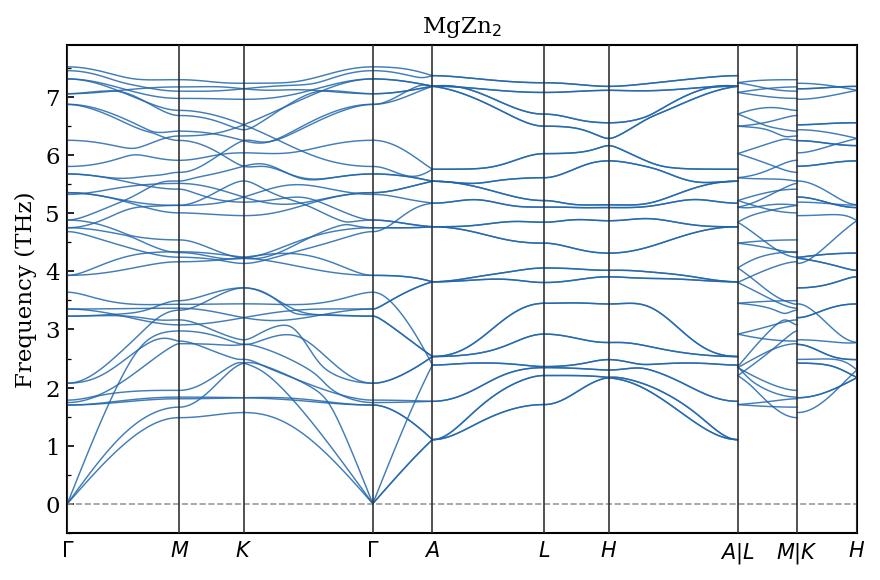

Saved: phonon_MgZn2_corrected.pdf  |  max freq = 7.5 THz


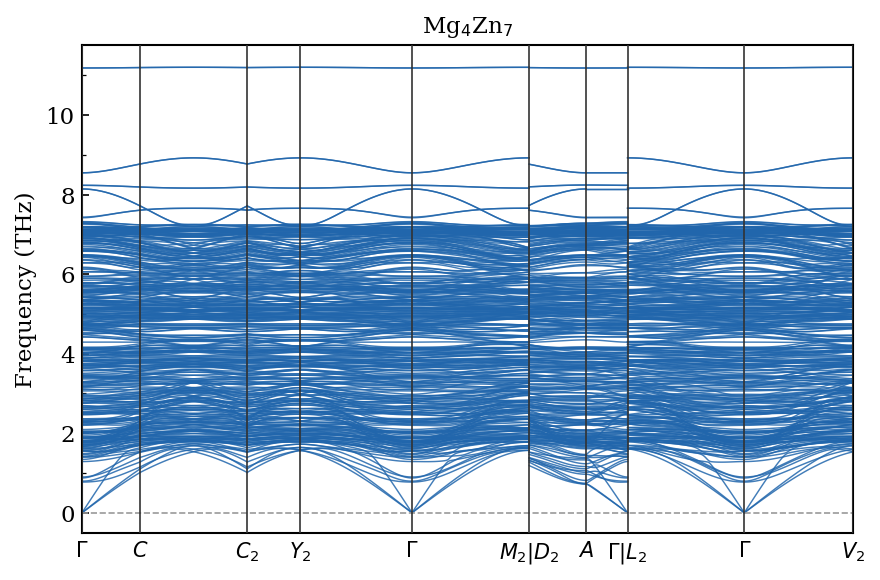

Saved: phonon_Mg4Zn7_corrected.pdf  |  max freq = 11.2 THz


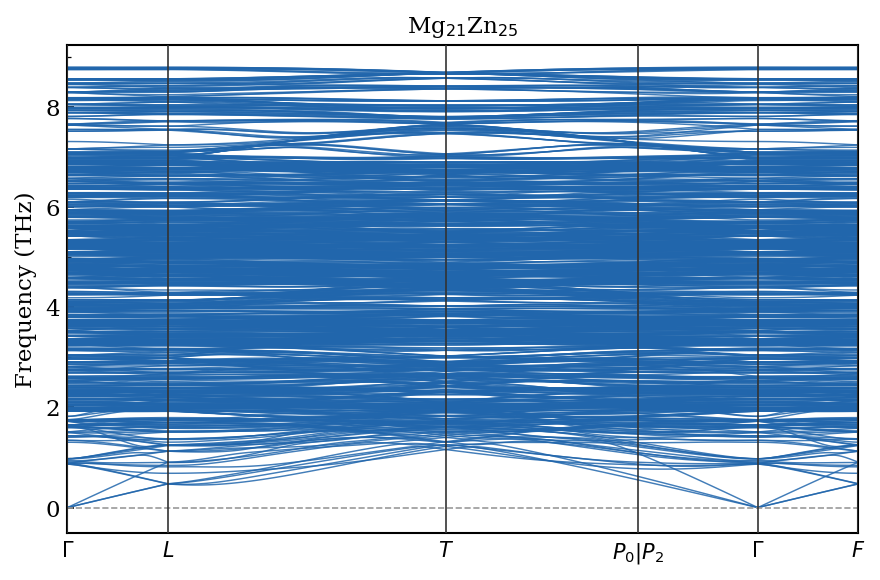

Saved: phonon_Mg21Zn25_corrected.pdf  |  max freq = 8.8 THz


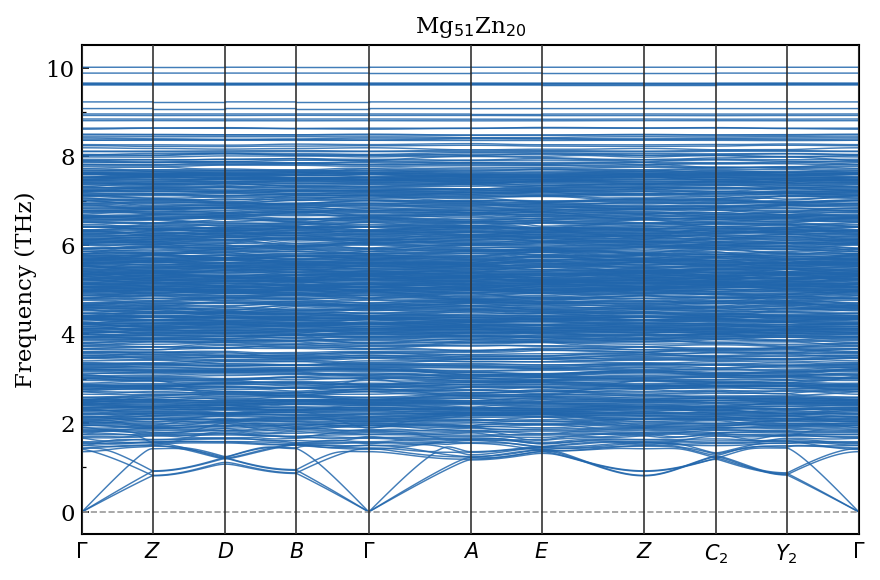

Saved: phonon_Mg51Zn20_corrected.pdf  |  max freq = 10.0 THz


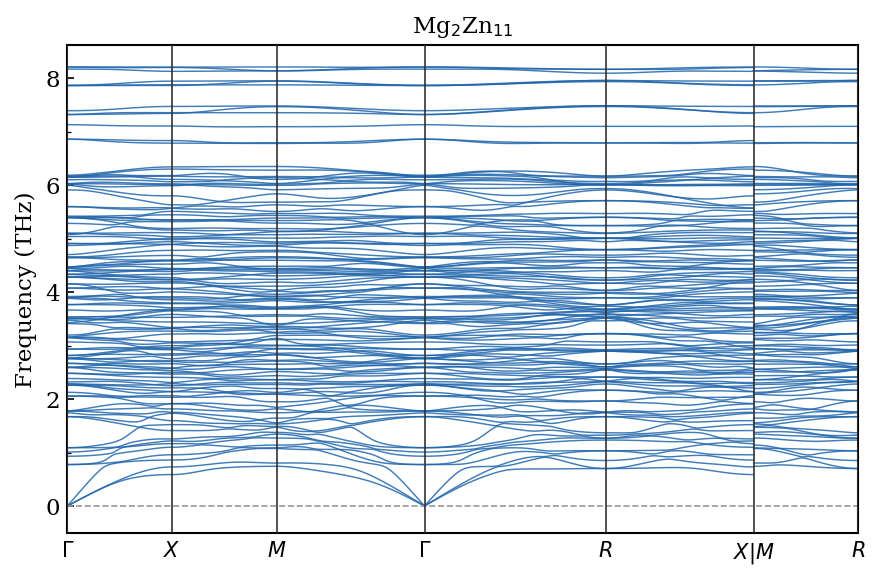

Saved: phonon_Mg2Zn11_corrected.pdf  |  max freq = 8.2 THz


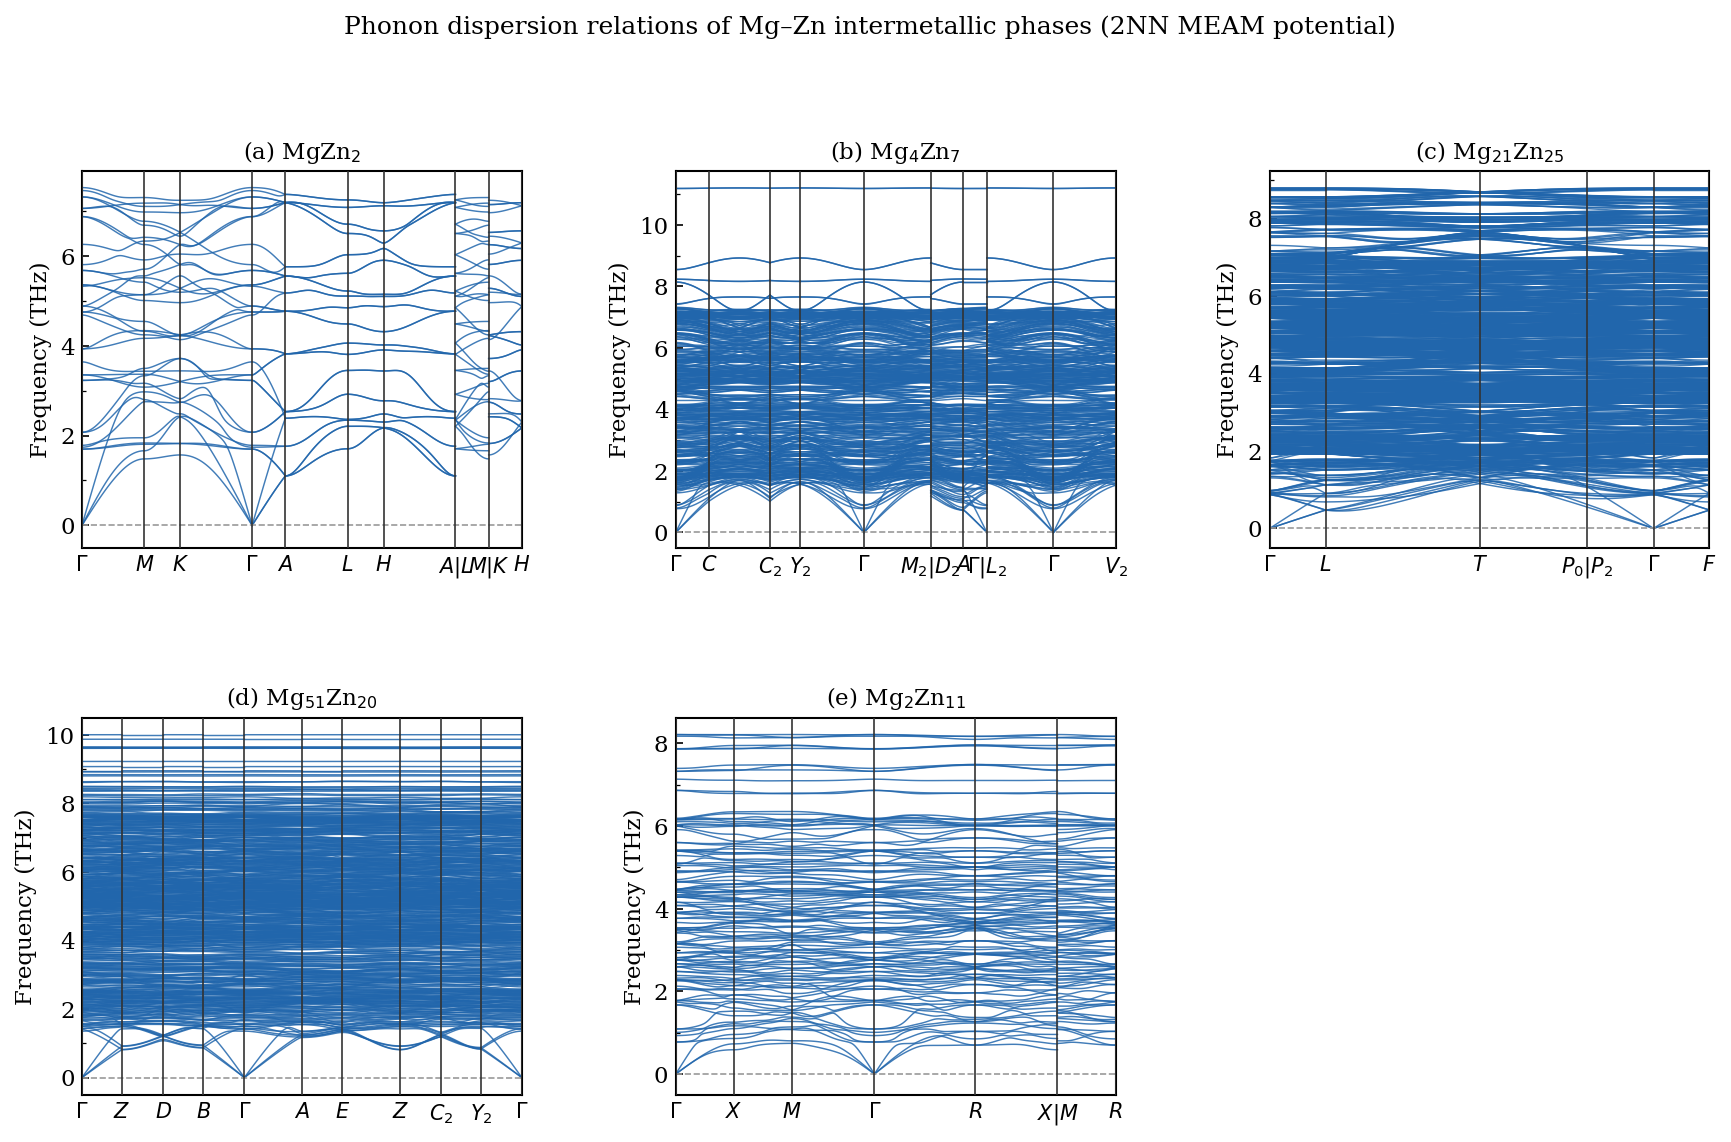

Saved: phonon_all_panels_corrected.pdf


In [2]:
#!/usr/bin/env python3
"""
phonon_band_plots_seekpath.py - WITH MASS CORRECTIONS
Final phonon band plots using full SeeK-path correct k-paths.
All paths verified against SeeK-path (Hinuma 2017 / Setyawan-Curtarolo 2010).
"""

import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'figure.dpi':        150,
    'axes.linewidth':    1.0,
    'lines.linewidth':   0.8,
})

BAND_COLOUR  = '#2166ac'
ZERO_COLOUR  = '#999999'
VLINE_COLOUR = '#333333'

# ═══════════════════════════════════════════════════════════════════
# MASS CORRECTION FACTORS FOR INTERMETALLICS
# ═══════════════════════════════════════════════════════════════════
correction_Mg = np.sqrt(1.008 / 24.305)     # 0.2036
correction_Zn_from_He = np.sqrt(4.003 / 65.38)  # 0.2473

# Composition-weighted corrections for each intermetallic
MASS_CORRECTIONS = {
    'MgZn$_2$':           (1/3) * correction_Mg + (2/3) * correction_Zn_from_He,      # 0.233
    'Mg$_4$Zn$_7$':       (4/11) * correction_Mg + (7/11) * correction_Zn_from_He,    # 0.231
    'Mg$_{21}$Zn$_{25}$': (21/46) * correction_Mg + (25/46) * correction_Zn_from_He,  # 0.227
    'Mg$_{51}$Zn$_{20}$': (51/71) * correction_Mg + (20/71) * correction_Zn_from_He,  # 0.216
    'Mg$_2$Zn$_{11}$':    (2/13) * correction_Mg + (11/13) * correction_Zn_from_He,   # 0.241
}

# ── Updated yaml paths pointing to regenerated files ──────────────────────────
YAML_FILES = {
    'MgZn$_2$':           'mgzn2_phonons/band.yaml',
    'Mg$_4$Zn$_7$':       'mg4zn7_phonons_good/band.yaml',
    'Mg$_{21}$Zn$_{25}$': 'mg21zn25_phonons/band.yaml',
    'Mg$_{51}$Zn$_{20}$': 'mg51zn20_phonons/band.yaml',
    'Mg$_2$Zn$_{11}$':    'mg2zn11_phonons_larger_distortions/band.yaml',
}

# ── SeeK-path verified k-point labels ─────────────────────────────────────────
KPOINT_LABELS = {
    'MgZn$_2$': {
        (0.0,   0.0,   0.0): r'$\Gamma$',
        (0.5,   0.0,   0.0): r'$M$',
        (0.333, 0.333, 0.0): r'$K$',
        (0.0,   0.0,   0.5): r'$A$',
        (0.5,   0.0,   0.5): r'$L$',
        (0.333, 0.333, 0.5): r'$H$',
    },
    'Mg$_4$Zn$_7$': {
        (0.0,    0.0,   0.0):  r'$\Gamma$',
        (0.261,  0.261, 0.0):  r'$C$',
        (-0.261, 0.739, 0.0):  r'$C_2$',
        (-0.5,   0.5,   0.0):  r'$Y_2$',
        (-0.5,   0.5,   0.5):  r'$M_2$',
        (0.256,  0.256, 0.5):  r'$D_2$',
        (0.0,    0.0,   0.5):  r'$A$',
        (0.0,    0.5,   0.5):  r'$L_2$',
        (0.0,    0.5,   0.0):  r'$V_2$',
    },
    'Mg$_{21}$Zn$_{25}$': {
        (0.0,    0.0,    0.0):   r'$\Gamma$',
        (0.5,    0.0,    0.0):   r'$L$',
        (0.5,   -0.5,    0.5):   r'$T$',
        (0.192, -0.808,  0.192): r'$P_0$',
        (0.192,  0.192,  0.192): r'$P_2$',
        (0.5,   -0.5,    0.0):   r'$F$',
    },
    'Mg$_{51}$Zn$_{20}$': {
        (0.0,  0.0,  0.0):  r'$\Gamma$',
        (0.0,  0.5,  0.0):  r'$Z$',
        (0.0,  0.5,  0.5):  r'$D$',
        (0.0,  0.0,  0.5):  r'$B$',
        (-0.5, 0.0,  0.5):  r'$A$',
        (-0.5, 0.5,  0.5):  r'$E$',
        (-0.5, 0.5,  0.0):  r'$C_2$',
        (-0.5, 0.0,  0.0):  r'$Y_2$',
    },
    'Mg$_2$Zn$_{11}$': {
        (0.0, 0.0, 0.0): r'$\Gamma$',
        (0.5, 0.0, 0.0): r'$X$',
        (0.5, 0.5, 0.0): r'$M$',
        (0.5, 0.5, 0.5): r'$R$',
    },
}

def round_q(q, decimals=3):
    return tuple(round(x, decimals) for x in q)

def plot_band(ax, yaml_path, label_dict, title, correction_factor=1.0):
    """
    Plot phonon band with mass correction applied.
    """
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    segments   = data['segment_nqpoint']
    phonon_pts = data['phonon']

    distances = np.array([pt['distance'] for pt in phonon_pts])
    
    freqs = np.array([[b['frequency'] for b in pt['band']]
                      for pt in phonon_pts]) * correction_factor

    seg_starts = [0]
    for s in segments[:-1]:
        seg_starts.append(seg_starts[-1] + s)

    for i, start in enumerate(seg_starts):
        end = start + segments[i]
        ax.plot(distances[start:end], freqs[start:end, :],
                color=BAND_COLOUR, lw=0.7, alpha=0.85)

    vline_pos    = []
    vline_labels = []

    idx = 0
    for i, s in enumerate(segments):
        q_start   = round_q(phonon_pts[idx]['q-position'])
        q_end     = round_q(phonon_pts[idx + s - 1]['q-position'])
        d_start   = phonon_pts[idx]['distance']
        d_end     = phonon_pts[idx + s - 1]['distance']
        lbl_start = label_dict.get(q_start, '')
        lbl_end   = label_dict.get(q_end,   '')

        if not vline_pos or abs(d_start - vline_pos[-1]) > 1e-6:
            vline_pos.append(d_start)
            vline_labels.append(lbl_start)
        else:
            prev = vline_labels[-1]
            if lbl_start and lbl_start != prev:
                vline_labels[-1] = prev + r'$|$' + lbl_start

        if abs(d_end - vline_pos[-1]) > 1e-6:
            vline_pos.append(d_end)
            vline_labels.append(lbl_end)
        else:
            prev = vline_labels[-1]
            if lbl_end and lbl_end != prev:
                vline_labels[-1] = prev + r'$|$' + lbl_end

        idx += s

    for pos in vline_pos:
        ax.axvline(x=pos, color=VLINE_COLOUR, lw=0.8, zorder=3)
    ax.axhline(y=0, color=ZERO_COLOUR, lw=0.8, ls='--', zorder=2)

    ax.set_xlim(distances[0], distances[-1])
    ax.set_xticks(vline_pos)
    ax.set_xticklabels(vline_labels, fontsize=10)
    ax.set_ylabel('Frequency (THz)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=6)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', direction='in')
    ax.set_ylim(bottom=min(0, freqs.min() - 0.5))

    return freqs.max()

# ── Individual figures ─────────────────────────────────────────────────────────
phases = list(YAML_FILES.keys())

for phase in phases:
    fig, ax = plt.subplots(figsize=(6, 4))
    fmax = plot_band(
        ax,
        YAML_FILES[phase],
        KPOINT_LABELS[phase],
        title=phase,
        correction_factor=MASS_CORRECTIONS[phase]  # APPLY CORRECTION
    )
    fig.tight_layout()
    safe_name = (phase.replace('$', '').replace('{', '')
                      .replace('}', '').replace('_', ''))
    fig.savefig(f'phonon_{safe_name}_corrected.pdf', bbox_inches='tight', dpi=300)
    fig.savefig(f'phonon_{safe_name}_corrected.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: phonon_{safe_name}_corrected.pdf  |  max freq = {fmax:.1f} THz")

# ── 5-panel summary figure ─────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(14, 8))
gs   = GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)
axes = [
    fig2.add_subplot(gs[0, 0]),
    fig2.add_subplot(gs[0, 1]),
    fig2.add_subplot(gs[0, 2]),
    fig2.add_subplot(gs[1, 0]),
    fig2.add_subplot(gs[1, 1]),
]
fig2.add_subplot(gs[1, 2]).set_visible(False)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

for i, (phase, ax) in enumerate(zip(phases, axes)):
    plot_band(
        ax,
        YAML_FILES[phase],
        KPOINT_LABELS[phase],
        title=f'{panel_labels[i]} {phase}',
        correction_factor=MASS_CORRECTIONS[phase]  # APPLY CORRECTION
    )

fig2.suptitle(
    'Phonon dispersion relations of Mg–Zn intermetallic phases '
    '(2NN MEAM potential)',
    fontsize=12, y=1.01
)
fig2.savefig('phonon_all_panels_corrected.pdf', bbox_inches='tight', dpi=300)
fig2.savefig('phonon_all_panels_corrected.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: phonon_all_panels_corrected.pdf")

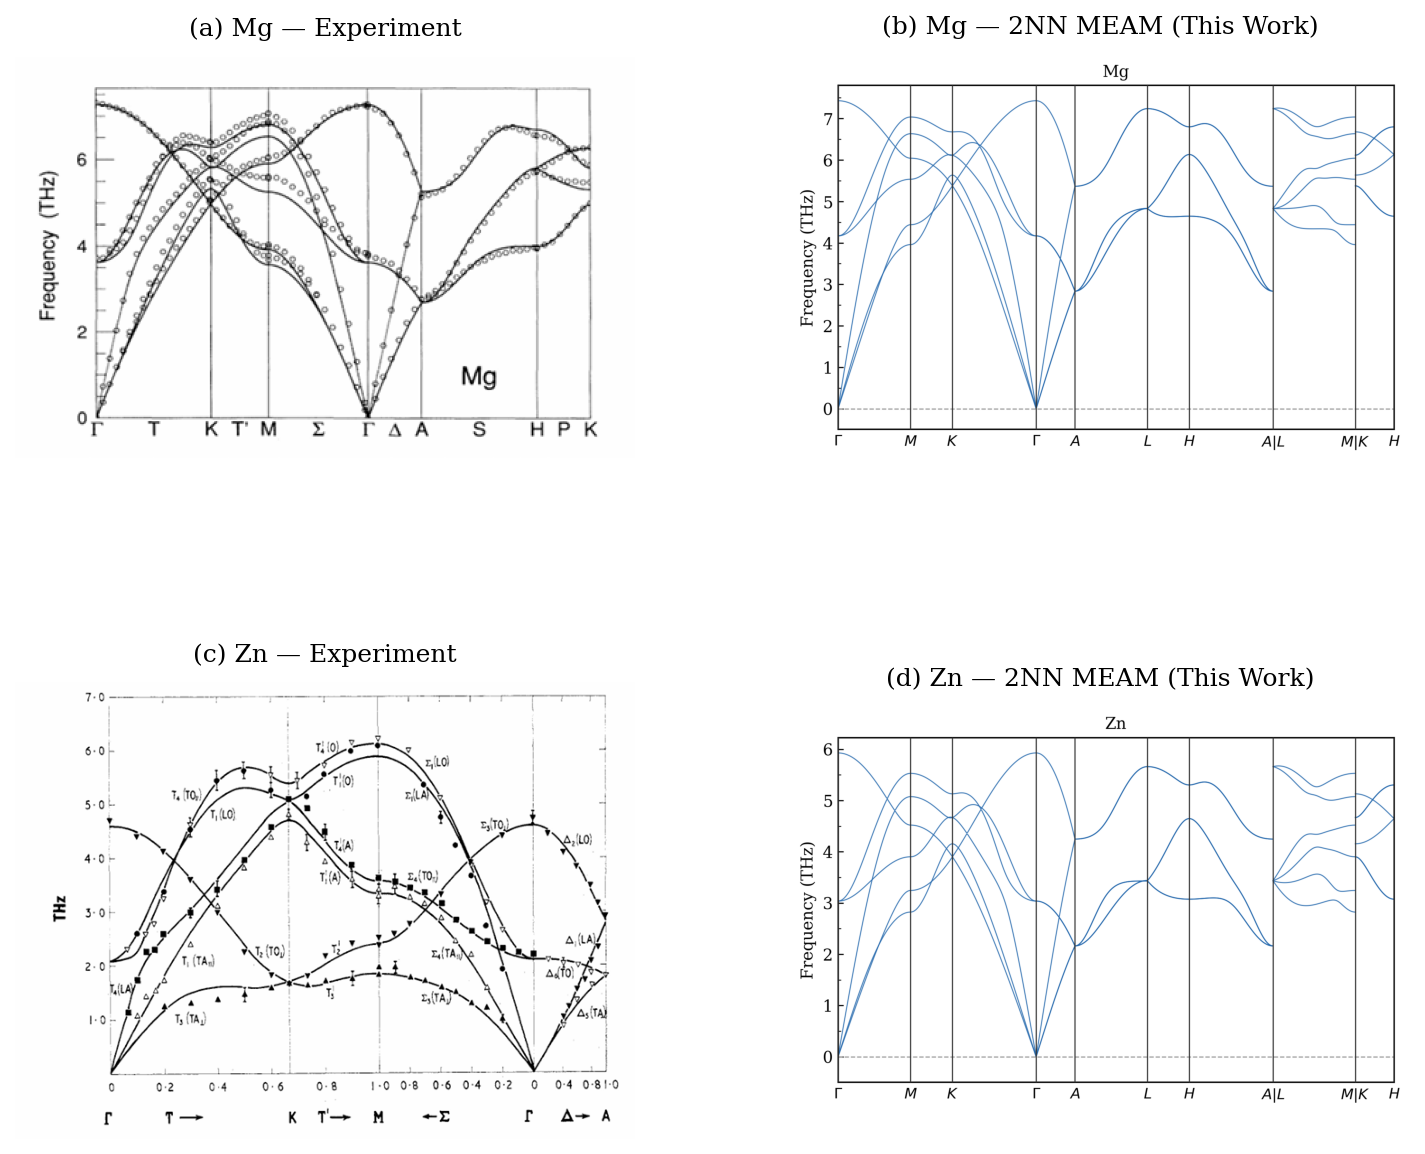

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

# Load images
mg_exp = Image.open('mg_exp_althoff1993.png')
zn_exp = Image.open('zn_exp_mcdonald1969.png')
mg_meam = Image.open('phonon_Mg_corrected.png')
zn_meam = Image.open('phonon_Zn_corrected.png')

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Display images
ax1.imshow(mg_exp)
ax1.set_title('(a) Mg — Experiment', fontsize=12, pad=10)
ax1.axis('off')

ax2.imshow(mg_meam)
ax2.set_title('(b) Mg — 2NN MEAM (This Work)', fontsize=12, pad=10)
ax2.axis('off')

ax3.imshow(zn_exp)
ax3.set_title('(c) Zn — Experiment', fontsize=12, pad=10)
ax3.axis('off')

ax4.imshow(zn_meam)
ax4.set_title('(d) Zn — 2NN MEAM (This Work)', fontsize=12, pad=10)
ax4.axis('off')

plt.savefig('phonon_comparison_exp_vs_meam.pdf', dpi=300, bbox_inches='tight')
plt.savefig('phonon_comparison_exp_vs_meam.png', dpi=300, bbox_inches='tight')
plt.show()